# Testing logistic gradient

In [15]:
import numpy as np
import numpy.linalg as la
from Testing_functions import logistic_regression, logistic_gradient
import matplotlib.pyplot as plt

In [16]:
from AdaAGM import AdaAGM
from Algorithms import constant_gradient, Nesterov_gradient, AdaNAG_G

## Loading datasets

In [17]:
from sklearn.datasets import load_svmlight_file
import os

#loading mushrooms data
data_path = os.getcwd() + '\\datasets\\mushrooms'

data_matrix, data_vector = load_svmlight_file(data_path)
A_mushrooms = data_matrix.toarray()
#vector has entries 1,2, function needs vector with values 0, 1
y_mushrooms = data_vector - np.ones(np.size(data_vector))

#loading w8a data
data_path = os.getcwd() + '\\datasets\\w8a'

data_matrix, data_vector = load_svmlight_file(data_path)
A_w8a = data_matrix.toarray()
#vector has entries 1, -1, function only takes values 0, 1
data_vector[data_vector== -1] = 0
y_w8a = data_vector

#loading covtype data
data_path = os.getcwd() + '\\datasets\\covtype.bz2'

data_matrix, data_vector = load_svmlight_file(data_path)
A_covtype = data_matrix.toarray()
#vector has entries 1, 2, 3, 4, 5, 6, 7, function only takes values 0, 1
data_vector[data_vector%2== 0] = 0
data_vector[data_vector%2== 1] = 1
y_covtype = data_vector

Setting up the data sets

In [18]:
t_0 = 2
m = 0.5
omega = 1/2
delta = 1/2
beta = 1
gamma = 1/2

In [19]:
matrices = [A_mushrooms, A_w8a, A_covtype]
vectors = [y_mushrooms, y_w8a, y_covtype]
iteration_list = [600, 1000, 9000]

In [20]:
tau_12 = lambda k: ((k+2) + 12)/12
alpha = lambda tau_k, tau_k1: 1/2 * (tau_k1 - 1)**2/tau_k**2
tau_m1 = tau_12(-1)
tau_0 = tau_12(0)
tau_1 = tau_12(1)
alpha_m1 = alpha(tau_m1, tau_0)
alpha_0 = alpha(tau_0, tau_1)
B_0 = alpha_0**2 * tau_0**2 *((tau_0-1)**2/(alpha_m1*tau_m1**2) - 1)

Set up initial stepsize list

In [21]:
def initial_stepize_AdaNAG_G_12(tau, alpha, B_0, L_0):
    """
    Calculate the initial stepsize of AdaNAG_G_12 given in the paper
    
    Note for AdaNAG_G_1/2: only the choice of r is different: r = 1/10
    """
    tau_m1 = tau(-1)
    tau_0 = tau(0)
    tau_1 = tau(1)
    
    alpha_0 = alpha(tau_m1, tau_0)
    alpha_1 = alpha(tau_0, tau_1)
    A_0 = alpha_1*tau_1*(tau_1 - 1)
    B_1 = alpha_1**2 * tau_1**2 * ((tau_1)**2/(alpha_0 * tau_0**2) - 1)

    r_0_L = 1/(A_0/B_0 + (B_1 + alpha_1**2 * tau_1**2)/A_0)
    r = alpha_1*r_0_L

    return A_0/(alpha_0*tau_0) * r/alpha_1 * 1/L_0

In [22]:
iterates = []
values = []
minimum = []
gradient_norms = []

for n in range(3):
    iterations = iteration_list[n]
    A = matrices[n]
    num_rows, num_cols = np.shape(A)
    y = vectors[n]
    
    #Lipschitz constant of problem: 
    #As in Testing Paper "An Adaptive and Parameter-Free Nesterov’s Accelerated Gradient Method for Convex Optimization"
    #L = 1/(4m) max_eigv(A^TA) + y 
    #using y = L/m we get: L = 1/(1- 1/m) * 1/(4m) max_eigv(A^TA)
    #using y = L/(10m) we get: L = 1/(1- 1/(10m)) * 1/(4m) max_eigv(A^TA)
    if n == 2:
        L = 1/(1-1/(10*num_rows)) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
        regularization = L / (10*num_rows)
    else:
        L = 1/(1-1/num_rows) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
        regularization = L / num_rows

    function = lambda x: logistic_regression(x, A, y, regularization)
    gradient = lambda x: logistic_gradient(x, A, y, regularization)
    
    x_0 = np.zeros(num_cols)
    y_0 = x_0
    
    #choice of initial stepsices
    #Nesterov and constant gradient require s_0 < 1/L
    s_0_const = 1/L
    #definition in Paper
    x_0_tilde = np.random.rand(num_cols)
    L_0 = la.norm(gradient(x_0) - gradient(x_0_tilde))/la.norm(x_0 - x_0_tilde)
    s_0_AdaNAG_G = initial_stepize_AdaNAG_G_12(tau_12, alpha, B_0, L_0)
    
    #Definition in Paper s_0 >= 1/(4L)
    s_0_AdaAGM = 1/(4*L)
    
    sol_const_gradient = constant_gradient(function, gradient, x_0, s_0_const, iterations)
    print('const_gradient Done')
    sol_Nesterov = Nesterov_gradient(function, gradient, x_0, s_0_const, iterations)
    print('Nesterov Done')
    sol_Ada_NAG_G = AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G, iterations, tau_12, alpha, B_0)
    print('AdaNAG_G Done')
    sol_AdaAGM = AdaAGM(function, gradient, x_0, y_0, gamma, t_0, m, s_0_AdaAGM, omega, delta, beta, iterations)
    print('AdaAGM Done')
    
    iterates.append([])
    iterates[n].append(sol_const_gradient[0])
    iterates[n].append(sol_Nesterov[0])
    iterates[n].append(sol_Ada_NAG_G[0])
    iterates[n].append(sol_AdaAGM[0])
    
    values.append([])
    values[n].append(sol_const_gradient[1])
    values[n].append(sol_Nesterov[1])
    values[n].append(sol_Ada_NAG_G[1])
    values[n].append(sol_AdaAGM[1])
    
    minimum.append(np.min(np.concatenate(values[n])))
    
    gradient_norms.append([])
    gradient_norms[n].append(sol_const_gradient[2])
    gradient_norms[n].append(sol_Nesterov[2])
    gradient_norms[n].append(sol_Ada_NAG_G[2])
    gradient_norms[n].append(sol_AdaAGM[2])

const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done
const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done
const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done


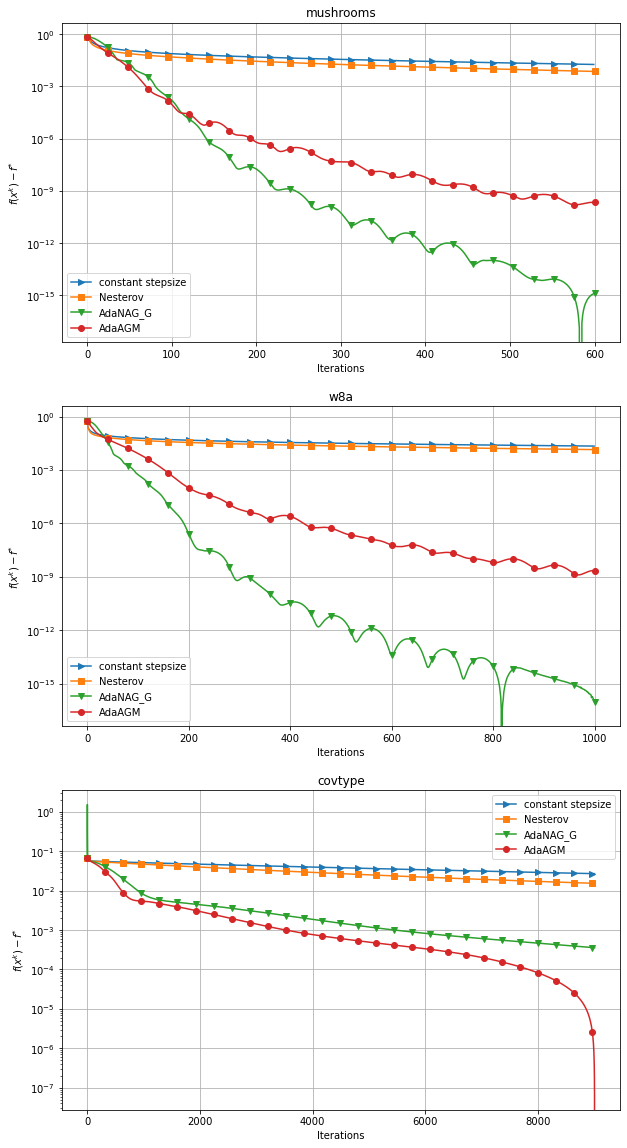

In [40]:
fig, ax = plt.subplots(3, figsize=(10,20))
labels = ['constant stepsize', 'Nesterov', 'AdaNAG_G', 'AdaAGM']
titles = ['mushrooms', 'w8a', 'covtype']
markers = ['>', 's', 'v', 'o']
mark_every = [24, 40, 320]
for k in range(3):
    for index, value_sequence in enumerate(values[k]):
        ax[k].plot(value_sequence - minimum[k], label=labels[index], marker=markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel('$f(x^{k}) - f^{*}$')
    ax[k].grid()

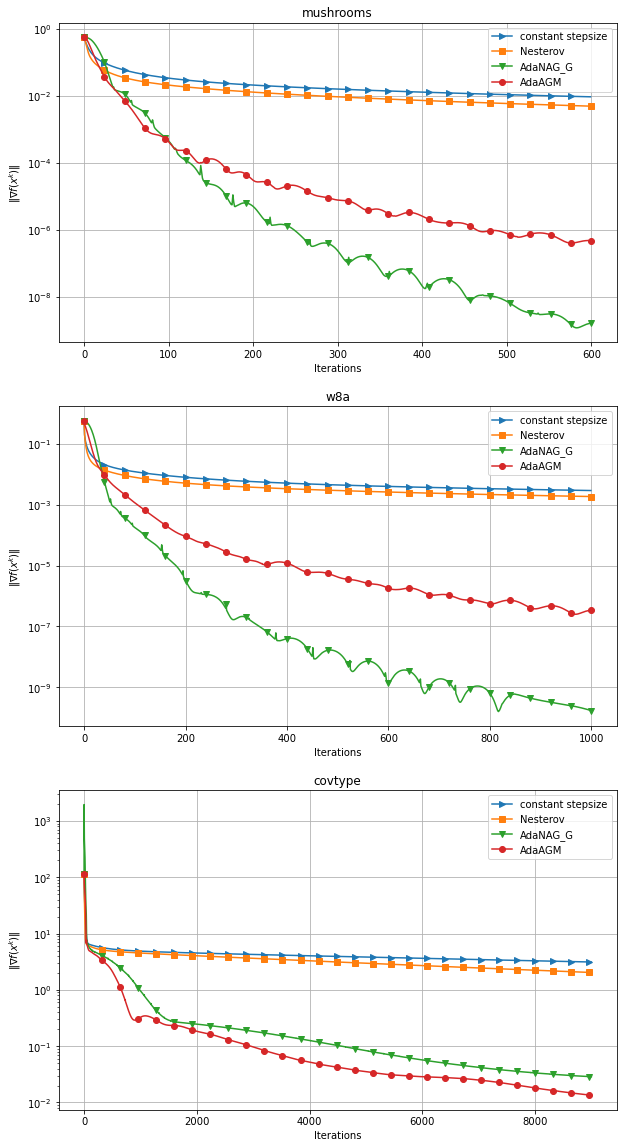

In [41]:
fig, ax = plt.subplots(3, figsize=(10,20))
for k in range(3):
    for index, gradient_sequence in enumerate(gradient_norms[k]):
        ax[k].plot(gradient_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$\Vert \nabla f(x^k) \Vert$')
    ax[k].grid()

# Testing

In [8]:
n = 1
iterations = iteration_list[n]
A = matrices[n]
num_rows, num_cols = np.shape(A)
y = vectors[n]

#Lipschitz constant of problem: 
#As in Testing Paper "An Adaptive and Parameter-Free Nesterov’s Accelerated Gradient Method for Convex Optimization"
#L = 1/(4m) max_eigv(A^TA) + y 
#using y = L/m we get: L = 1/(1- 1/m) * 1/(4m) max_eigv(A^TA)
#using y = L/(10m) we get: L = 1/(1- 1/(10m)) * 1/(4m) max_eigv(A^TA)
if n == 2:
    L = 1/(1-1/(10*num_rows)) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
    regularization = L / (10*num_rows)
else:
    L = 1/(1-1/num_rows) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
    regularization = L / num_rows

function = lambda x: logistic_regression(x, A, y, regularization)
gradient = lambda x: logistic_gradient(x, A, y, regularization)

x_0 = np.zeros(num_cols)
y_0 = x_0

#choice of initial stepsices
#Nesterov and constant gradient require s_0 < 1/L
s_0_const = 1/L
#definition in Paper
x_0_tilde = np.random.rand(num_cols)
L_0 = la.norm(gradient(x_0) - gradient(x_0_tilde))/la.norm(x_0 - x_0_tilde)
s_0_AdaNAG_G = initial_stepize_AdaNAG_G_12(tau_12, alpha, B_0, L_0)

#Definition in Paper s_0 >= 1/(4L)
s_0_AdaAGM = 1/(4*L)

In [9]:
#sol_const_gradient = constant_gradient(function, gradient, x_0, s_0_const, 30)
#sol_Nesterov = Nesterov_gradient(function, gradient, x_0, s_0_const, iterations)
sol_Ada_NAG_G = AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G, iterations, tau_12, alpha, B_0)
#sol_AdaAGM = AdaAGM(function, gradient, x_0, y_0, gamma, t_0, m, s_0_AdaAGM, omega, delta, beta, iterations)

In [11]:
sol_Ada_NAG_G[1][-1]

0.12321592893994672